<a href="https://colab.research.google.com/github/sanvi-g07/ml-zoomcamp/blob/main/ml_zoomcamp_hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Get data

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [174]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2026-08-11 19:05:39--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.5’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.008s  

2026-08-11 19:05:39 (10.0 MB/s) - ‘course_lead_scoring.csv.5’ saved [80876/80876]



In [175]:
df = pd.read_csv("course_lead_scoring.csv")

#Data preparation

In [176]:
df.dtypes

,0
lead_source,object
industry,object
number_of_courses_viewed,int64
annual_income,float64
employment_status,object
location,object
interaction_count,int64
lead_score,float64
converted,int64


In [177]:
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [178]:
df[numerical].isnull().sum()

,0
number_of_courses_viewed,0
annual_income,181
interaction_count,0
lead_score,0


In [179]:
df[numerical] = df[numerical].fillna(0)

In [180]:
df[numerical].isnull().sum()

,0
number_of_courses_viewed,0
annual_income,0
interaction_count,0
lead_score,0


In [181]:
df[categorical].isnull().sum()

,0
lead_source,128
industry,134
employment_status,100
location,63


In [182]:
df[categorical] = df[categorical].fillna('NA')

In [183]:
df[categorical].isnull().sum()

,0
lead_source,0
industry,0
employment_status,0
location,0


#Split data

In [184]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [185]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [186]:
len(df_full_train), len(df_train), len(df_val), len(df_test)

(1169, 876, 293, 293)

In [187]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [188]:
y_full_train = df_full_train['converted']
y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

In [189]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

#ROC AUC feature importance

In [190]:
for n in numerical:
  fpr, tpr, thresholds = roc_curve(y_train, df_train[n])
  print(n, auc(fpr, tpr))

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


# Train and predict

In [191]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [192]:
dv, model = train(df_train, y_train)

In [193]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [194]:
y_pred_val = predict(df_val, dv, model)

#Precision and Recall

In [195]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val)
auc(fpr, tpr)

np.float64(0.8171316268814112)

In [196]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
  actual_pos = (y_val == 1)
  actual_neg = (y_val == 0)
  predicted_pos = (y_pred_val >= t)
  predicted_neg = (y_pred_val < t)

  tp = (actual_pos & predicted_pos).sum()
  tn = (actual_neg & predicted_neg).sum()
  fp = (actual_neg & predicted_pos).sum()
  fn = (actual_pos & predicted_neg).sum()

  scores.append((t, tp, fp, fn, tn))

In [197]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)

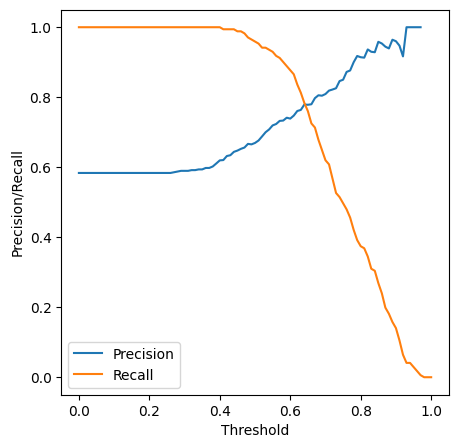

In [198]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.threshold, df_scores.precision, label="Precision")
plt.plot(df_scores.threshold, df_scores.recall, label="Recall")

plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')

plt.legend()

#F1 Score

In [199]:
df_scores['f1_score'] = 2 * (df_scores.precision * df_scores.recall)/(df_scores.precision + df_scores.recall)
df_scores

,threshold,tp,fp,fn,tn,tpr,fpr,precision,recall,f1_score
0,0.00,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.737069
1,0.01,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.737069
2,0.02,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.737069
3,0.03,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.737069
4,0.04,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.737069
...,...,...,...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,0.017544,0.0,1.000000,0.017544,0.034483
97,0.97,1,0,170,122,0.005848,0.0,1.000000,0.005848,0.011628
98,0.98,0,0,171,122,0.000000,0.0,NaN,0.000000,NaN
99,0.99,0,0,171,122,0.000000,0.0,NaN,0.000000,NaN


In [200]:
df_scores.loc[df_scores.f1_score.idxmax(), 'threshold']

np.float64(0.5700000000000001)

#Cross-Validation

In [201]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []

for train_idx, val_idx in kfold.split(df_full_train):
  df_train = df_full_train.iloc[train_idx]
  df_val = df_full_train.iloc[val_idx]

  y_train = df_train['converted'].values
  y_val = df_val['converted'].values

  dv, model = train(df_train, y_train)
  y_pred_val = predict(df_val, dv, model)

  auc = roc_auc_score(y_val, y_pred_val)
  auc_scores.append(auc)

auc_scores

[np.float64(0.8060745924216483),
 np.float64(0.8713738368910783),
 np.float64(0.7754320118852139),
 np.float64(0.8018368617683685),
 np.float64(0.8558272713202291)]

In [202]:
np.std(auc_scores)

np.float64(0.03580711942905165)

#Hyperparameter Tuning

In [205]:
for c in [0.000001, 0.001, 1]:
  kfold = KFold(n_splits=5, shuffle=True, random_state=1)
  auc_scores = []

  for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train['converted'].values
    y_val = df_val['converted'].values

    dv, model = train(df_train, y_train, C=c)
    y_pred_val = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred_val)
    auc_scores.append(auc)

  print(c, np.mean(auc_scores), np.std(auc_scores))

1e-06 0.560207852870275 0.023798316620649906
0.001 0.8668780317675395 0.028746230508215103
1 0.8221089148573075 0.03580711942905165
